# MDR-TS v11.1 (Rain Only Model)

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR  
**Last Updated:** Tue Feb 11, 2026

---

## Why this exists

Our main goal is to model rain and seasonality a lot better. This notebook serves that purpose. Previous baselines have struggled with wet periods and seasonal transitions, so we want to focus on those hard cases. This will be a more focused effort than the general-purpose baselines, and it will help us understand how much we can improve by targeting these specific challenges.

---

## Model Summary

- **Task:** Regression (rain)  
- **Target:** `rain_mm` or `percip_mm`  
- **Temporal resolution:** Daily
- **Baseline model:** XGBoost (single model first)

Simplified:
- Predicting `y = log1p(precip_mm)`

---

## Reproducibility

- **Random seed:** 42  
- **Split:** `/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new`  
- **Environment:** local (MacBook M2 Pro)

---

# 🚨 🚨 🚨 IMPORTANT MODELING NOTE 🚨 🚨 🚨

This is not a rainfall forecasting model.

It does not predict rain at `t+1`
It is not a standalone atmospheric contribution.

It is a rain-state encoder.

> The purpose is simple: learn a structured, nonlinear representation of rainfall at time t that improves soil moisture prediction.


In [1]:
import os
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

from optuna.visualization import plot_optimization_history, plot_param_importances

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("imports loaded")
print(f"seed: {SEED}")

imports loaded
seed: 42


In [2]:
# Project paths
VERSION = "v11"
SUBVERSION = "v11.1"
RUN_NAME = "mdr_ts_v11_1"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

# Create output directory if missing
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v11/v11.1

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


In [3]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_new/train_derived_new.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_new/val_derived_new.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_new/test_derived_new.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

DROP_COLS = ["slope", "elev"]

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    cols_present = [c for c in DROP_COLS if c in d.columns]
    d.drop(columns=cols_present, inplace=True)
    print(f"{name}: dropped columns {cols_present}")
    print(f"\n{name}: shape={d.shape}")
    print(f"{name}: columns={len(d.columns)}")

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new/train_derived_new.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new/val_derived_new.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new/test_derived_new.csv
train: dropped columns ['slope', 'elev']

train: shape=(16972, 354)
train: columns=354
val: dropped columns ['slope', 'elev']

val: shape=(2919, 354)
val: columns=354
test: dropped columns ['slope', 'elev']

test: shape=(2829, 354)
test: columns=354


In [4]:
# Dropping TouchNet because it has no rows in the validation split

DROP_STATION = "Touchet_WA_824"

def drop_station(df, station_id=DROP_STATION):
    before = len(df)
    out = df[df["station_id"] != station_id].copy()
    after = len(out)
    print(f"Dropped {station_id}: {before} -> {after} rows (-{before-after})")
    return out

train_df = drop_station(train_df)
val_df   = drop_station(val_df)
test_df  = drop_station(test_df)

Dropped Touchet_WA_824: 16972 -> 13661 rows (-3311)
Dropped Touchet_WA_824: 2919 -> 2919 rows (-0)
Dropped Touchet_WA_824: 2829 -> 2659 rows (-170)


In [5]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 354

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'aspect', 'DOY', 'soil_moisture_5cm', 'D_sin_DOY', 'D_cos_DOY', 'F_NDVI', 'F_NDMI', 'F_MSI', 'E_SAR_ratio', 'E_SAR_diff', 'G_API', 'G_DSLR', 'G_rain_sum_3d', 'G_rain_sum_7d', 'G_rain_sum_30d', 'A_d_G_API_kobs1', 'A_d_G_API_kobs2', 'A_d_G_API_kobs5']


In [9]:
TARGET_COL = "precip_mm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [

    # rain memory / API
    "G_rain_sum_3d",
    "G_rain_sum_7d",
    "G_rain_sum_30d",
    "G_API",
    "V_rollmean_G_API_kobs7",
    "A_grad_G_API_kobs7",
    "C_lag_G_API_kobs1",

    # atmospheric state
    "LST_modis",

    # SAR / surface wetness indicators
    "s1_vh",
    "E_SAR_ratio",
    "E_SAR_diff",
    "F_NDMI",
    "F_MSI",

    # optical bands
    "s2_b8",
    "s2_b12",

    # static terrain
    # "elev",  # optional re-add
    # "slope", # optional re-add
    "aspect",

    # seasonal encoding (must be created beforehand)
    "D_sin_DOY",
    "D_cos_DOY",
]

# ==============================
# Validation
# ==============================

expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])

missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Rain baseline columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Rain baseline columns locked
  Features: 18
  Target:   precip_mm


In [27]:
X_train = train_df[FEATURE_COLS].copy()
X_val   = val_df[FEATURE_COLS].copy()
X_test  = test_df[FEATURE_COLS].copy()

y_train = np.log1p(train_df[TARGET_COL].astype(float).to_numpy())
y_train_log = y_train

y_val_mm  = val_df[TARGET_COL].astype(float).to_numpy()
y_test_mm = test_df[TARGET_COL].astype(float).to_numpy()

y_val_log   = np.log1p(y_val_mm)
y_test_log = np.log1p(y_test_mm)

X_train = X_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

print("X/y ready (rain baseline)")
print("  X_train:", X_train.shape, "y_train(log):", y_train.shape)
print("  X_val:  ", X_val.shape,   "y_val(mm):   ", y_val_mm.shape)
print("  X_test: ", X_test.shape,  "y_test(mm):  ", y_test_mm.shape)

X/y ready (rain baseline)
  X_train: (13661, 18) y_train(log): (13661,)
  X_val:   (2919, 18) y_val(mm):    (2919,)
  X_test:  (2659, 18) y_test(mm):   (2659,)


In [18]:
feature_summary = pd.DataFrame({
    "mean": X_train.mean(),
    "std": X_train.std(),
    "min": X_train.min(),
    "max": X_train.max(),
}).sort_values("std", ascending=False)

feature_summary # interactive sheet

,mean,std,min,max
G_rain_sum_30d,141.161408,158.505265,0.000000,1100.500000
C_lag_G_API_kobs1,46.983869,54.991098,0.000000,408.757381
G_API,46.985479,54.988804,0.000000,408.757381
V_rollmean_G_API_kobs7,47.008306,53.686270,0.016553,362.399376
G_rain_sum_7d,37.330378,52.907762,0.000000,477.000000
G_rain_sum_3d,18.783969,30.828038,0.000000,259.400000
aspect,164.904173,15.197338,142.090762,183.089635
LST_modis,288.578191,11.373571,248.913937,316.363128
A_grad_G_API_kobs7,0.014515,4.440098,-25.222883,34.970810
E_SAR_ratio,4.889251,1.001570,2.420810,8.049545


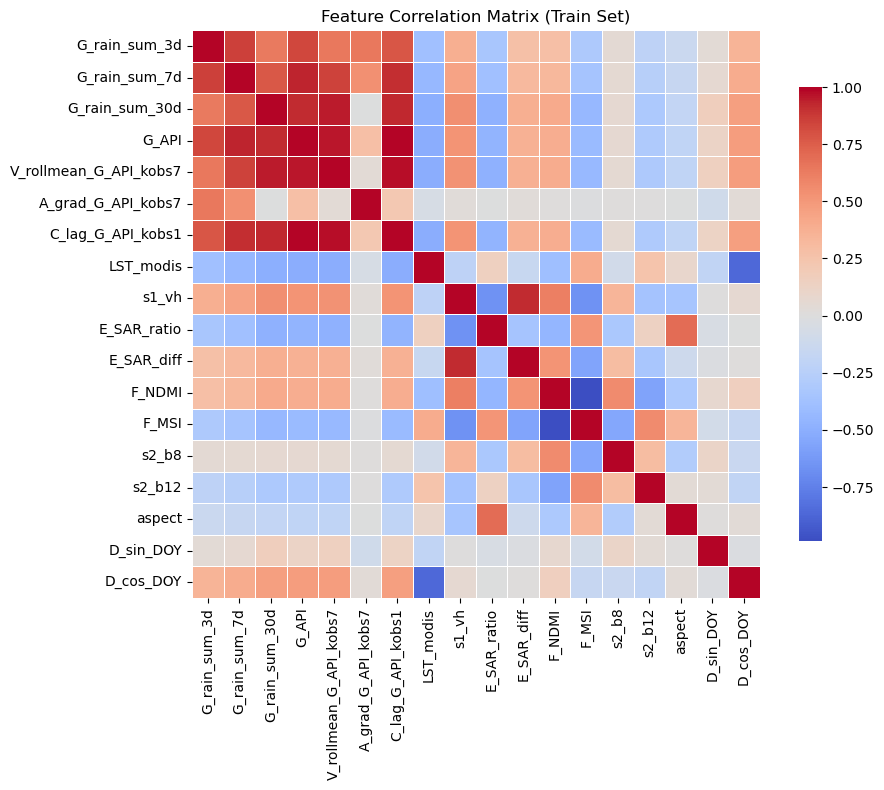

In [19]:
corr = X_train.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix (Train Set)")
plt.tight_layout()
plt.show()

## Baseline
---

In [20]:
model = XGBRegressor(
    n_estimators=800,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    tree_method="hist",
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [21]:
pred_log = model.predict(X_val)
pred_mm  = np.expm1(pred_log)
y_val_log = np.log1p(y_val_mm)

print("VAL R2:", r2_score(y_val_mm, pred_mm))
print("VAL R2 (log-space):", r2_score(y_val_log, pred_log))
print("VAL MAE:", mean_absolute_error(y_val_mm, pred_mm))
print("VAL RMSE:", np.sqrt(mean_squared_error(y_val_mm, pred_mm)))
print("True mean:", np.mean(y_val_mm))
print("Pred mean:", np.mean(pred_mm))

VAL R2: 0.8466678275122854
VAL R2 (log-space): 0.9029268870790931
VAL MAE: 1.4818580704965518
VAL RMSE: 4.466298587568098
True mean: 5.002226789996574
Pred mean: 4.2655897


In [24]:
print("zero-rain portion:", round(np.mean(y_val_mm == 0) * 100, ndigits=0), "%")

zero-rain portion: 42.0 %


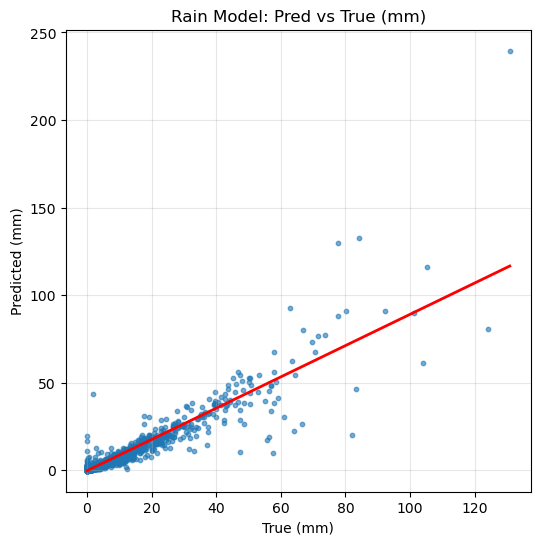

In [40]:
plt.figure(figsize=(6,6))
plt.scatter(y_val_mm, pred_mm, s=10, alpha=0.6)

m, b = np.polyfit(y_val_mm, pred_mm, 1)
x_line = np.linspace(0, y_val_mm.max(), 100)
y_line = m * x_line + b

plt.plot(x_line, y_line, color="red", linewidth=2)

plt.xlabel("True (mm)")
plt.ylabel("Predicted (mm)")
plt.title("Rain Model: Pred vs True (mm)")
plt.grid(alpha=0.3)

plt.show()

## Aggressive
---

In [29]:
model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    gamma=0.1,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train_log,
    eval_set=[(X_val, y_val_log)],
    verbose=100,
)

[0]	validation_0-rmse:1.14807
[100]	validation_0-rmse:0.76483
[200]	validation_0-rmse:0.62875
[300]	validation_0-rmse:0.56356
[400]	validation_0-rmse:0.51909
[500]	validation_0-rmse:0.48020
[600]	validation_0-rmse:0.45477
[700]	validation_0-rmse:0.43227
[800]	validation_0-rmse:0.41283
[900]	validation_0-rmse:0.39274
[1000]	validation_0-rmse:0.37712
[1100]	validation_0-rmse:0.36457
[1200]	validation_0-rmse:0.35537
[1300]	validation_0-rmse:0.34627
[1400]	validation_0-rmse:0.33789
[1500]	validation_0-rmse:0.33175
[1600]	validation_0-rmse:0.32495
[1700]	validation_0-rmse:0.32045
[1800]	validation_0-rmse:0.31578
[1900]	validation_0-rmse:0.31151
[2000]	validation_0-rmse:0.30764
[2100]	validation_0-rmse:0.30478
[2200]	validation_0-rmse:0.30218
[2300]	validation_0-rmse:0.30020
[2400]	validation_0-rmse:0.29873
[2500]	validation_0-rmse:0.29775
[2600]	validation_0-rmse:0.29662
[2700]	validation_0-rmse:0.29569
[2800]	validation_0-rmse:0.29515
[2900]	validation_0-rmse:0.29444
[2999]	validation_0-rm

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [33]:
pred_val_log = model.predict(X_val)
pred_val_mm  = np.expm1(pred_val_log)

# Metrics (mm space + log space)
print("VAL R2 (mm):      ", r2_score(y_val_mm, pred_val_mm))
print("VAL R2 (log):     ", r2_score(y_val_log, pred_val_log))
print("VAL MAE (mm):     ", mean_absolute_error(y_val_mm, pred_val_mm))
print("VAL RMSE (mm):    ", np.sqrt(mean_squared_error(y_val_mm, pred_val_mm)))
print("VAL mean true mm: ", float(np.mean(y_val_mm)))
print("VAL mean pred mm: ", float(np.mean(pred_val_mm)))

VAL R2 (mm):       0.8863602616400876
VAL R2 (log):      0.9352853507167588
VAL MAE (mm):      1.1503421684010295
VAL RMSE (mm):     3.8449989174494483
VAL mean true mm:  5.002226789996574
VAL mean pred mm:  4.373898506164551


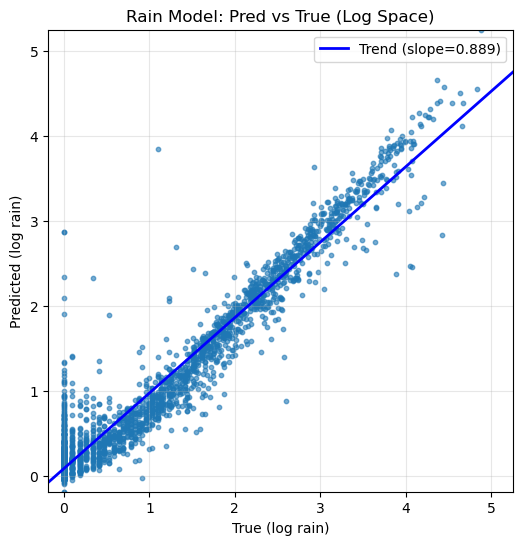

In [41]:
plt.figure(figsize=(6,6))
plt.scatter(y_val_log, pred_val_log, s=10, alpha=0.6)

min_val = min(y_val_log.min(), pred_val_log.min())
max_val = max(y_val_log.max(), pred_val_log.max())

m, b = np.polyfit(y_val_log, pred_val_log, 1)
x_line = np.linspace(min_val, max_val, 100)
y_line = m * x_line + b

plt.plot(x_line, y_line,
         color="blue",
         linewidth=2,
         label=f"Trend (slope={m:.3f})")

plt.xlabel("True (log rain)")
plt.ylabel("Predicted (log rain)")
plt.title("Rain Model: Pred vs True (Log Space)")
plt.grid(alpha=0.3)
plt.legend()

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.show()

## Importance Pruning
---

In [42]:
imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("Top 20 features:")
display(imp.head(20))

print("\nBottom 20 features:")
display(imp.tail(20))

Top 20 features:


G_rain_sum_3d             0.368963
G_API                     0.144153
C_lag_G_API_kobs1         0.136419
G_rain_sum_7d             0.062097
A_grad_G_API_kobs7        0.048840
V_rollmean_G_API_kobs7    0.038618
G_rain_sum_30d            0.028482
LST_modis                 0.024808
D_sin_DOY                 0.017306
s2_b12                    0.016896
F_NDMI                    0.016628
D_cos_DOY                 0.015640
s1_vh                     0.014939
E_SAR_ratio               0.013908
F_MSI                     0.013885
E_SAR_diff                0.013519
s2_b8                     0.013110
aspect                    0.011791
dtype: float32


Bottom 20 features:


G_rain_sum_3d             0.368963
G_API                     0.144153
C_lag_G_API_kobs1         0.136419
G_rain_sum_7d             0.062097
A_grad_G_API_kobs7        0.048840
V_rollmean_G_API_kobs7    0.038618
G_rain_sum_30d            0.028482
LST_modis                 0.024808
D_sin_DOY                 0.017306
s2_b12                    0.016896
F_NDMI                    0.016628
D_cos_DOY                 0.015640
s1_vh                     0.014939
E_SAR_ratio               0.013908
F_MSI                     0.013885
E_SAR_diff                0.013519
s2_b8                     0.013110
aspect                    0.011791
dtype: float32

In [47]:
def eval_model(feature_cols):
    Xtr = train_df[feature_cols]
    Xva = val_df[feature_cols]

    ytr_log = y_train_log
    yva_log = y_val_log

    m = XGBRegressor(
        n_estimators=3000,
        learning_rate=0.01,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        gamma=0.1,
        random_state=42,
        tree_method="hist",
    )

    m.fit(
        Xtr, ytr_log,
        eval_set=[(Xva, yva_log)],
        verbose=False,
    )

    pred_log = m.predict(Xva)
    pred_mm  = np.expm1(pred_log)

    r2_mm  = r2_score(y_val_mm, pred_mm)
    r2_log = r2_score(yva_log, pred_log)
    mae    = mean_absolute_error(y_val_mm, pred_mm)
    rmse   = np.sqrt(mean_squared_error(y_val_mm, pred_mm))

    return m, r2_mm, r2_log, mae, rmse

In [48]:
cuts = [1.00, 0.75, 0.50, 0.33, 0.25]
results = []

for frac in cuts:
    k = max(5, int(np.ceil(len(FEATURE_COLS) * frac)))
    cols_k = imp.index[:k].tolist()
    m_k, r2_mm, r2_log, mae, rmse = eval_model(cols_k)
    results.append((frac, k, r2_mm, r2_log, mae, rmse))

res_df = pd.DataFrame(results, columns=["keep_frac","k_features","R2_mm","R2_log","MAE_mm","RMSE_mm"])
display(res_df.sort_values("R2_log", ascending=False))

,keep_frac,k_features,R2_mm,R2_log,MAE_mm,RMSE_mm
4,0.25,5,0.903053,0.938924,1.001462,3.551383
0,1.00,18,0.891990,0.936500,1.122172,3.748544
2,0.50,9,0.900781,0.936459,1.080453,3.592767
1,0.75,14,0.892327,0.935178,1.133929,3.742699
3,0.33,6,0.902341,0.931417,1.117205,3.564401


In [50]:
# go even smaller since apparently less is more here...doesn't make a whole lotta sense, but we're gonna roll wit it
ks = [3,4,5,6,7,8,9,10]

results = []

for k in ks:
    cols_k = imp.index[:k].tolist()
    m_k, r2_mm, r2_log, mae, rmse = eval_model(cols_k)
    results.append((k, r2_mm, r2_log, mae, rmse))

res_df = pd.DataFrame(results, columns=["k_features","R2_mm","R2_log","MAE_mm","RMSE_mm"])
display(res_df.sort_values("R2_log", ascending=False))

,k_features,R2_mm,R2_log,MAE_mm,RMSE_mm
1,4,0.932767,0.939195,0.986937,2.957478
2,5,0.903053,0.938924,1.001462,3.551383
7,10,0.905432,0.938609,1.058377,3.507540
5,8,0.908264,0.937455,1.054225,3.454628
6,9,0.900781,0.936459,1.080453,3.592767
4,7,0.897612,0.935460,1.072370,3.649681
3,6,0.902341,0.931417,1.117205,3.564401
0,3,0.905045,0.930812,1.236669,3.514709


In [51]:
imp.head(5)

G_rain_sum_3d         0.368963
G_API                 0.144153
C_lag_G_API_kobs1     0.136419
G_rain_sum_7d         0.062097
A_grad_G_API_kobs7    0.048840
dtype: float32

In [52]:
imp.head(10)

G_rain_sum_3d             0.368963
G_API                     0.144153
C_lag_G_API_kobs1         0.136419
G_rain_sum_7d             0.062097
A_grad_G_API_kobs7        0.048840
V_rollmean_G_API_kobs7    0.038618
G_rain_sum_30d            0.028482
LST_modis                 0.024808
D_sin_DOY                 0.017306
s2_b12                    0.016896
dtype: float32

In [ ]:
model.get_booster().get_score(importance_type="gain")

---

## Results

Baseline:

```
VAL R2: 0.8466678275122854
VAL R2 (log-space): 0.9029268870790931
VAL MAE: 1.4818580704965518
VAL RMSE: 4.466298587568098
True mean: 5.002226789996574
Pred mean: 4.2655897
```

Aggressive:
```
VAL R2 (mm):       0.8863602616400876
VAL R2 (log):      0.9352853507167588
VAL MAE (mm):      1.1503421684010295
VAL RMSE (mm):     3.8449989174494483
VAL mean true mm:  5.002226789996574
VAL mean pred mm:  4.373898506164551
```


